The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


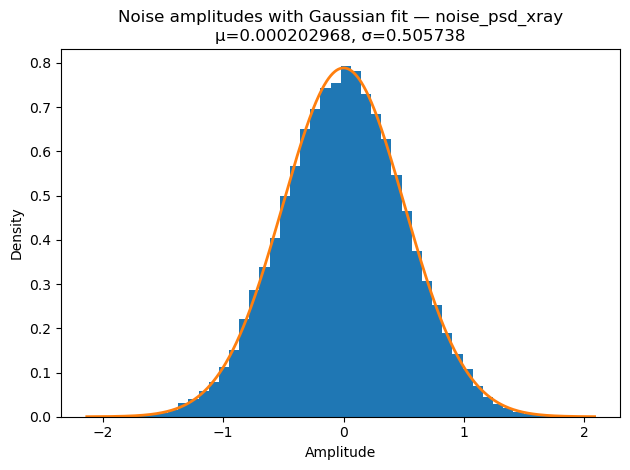

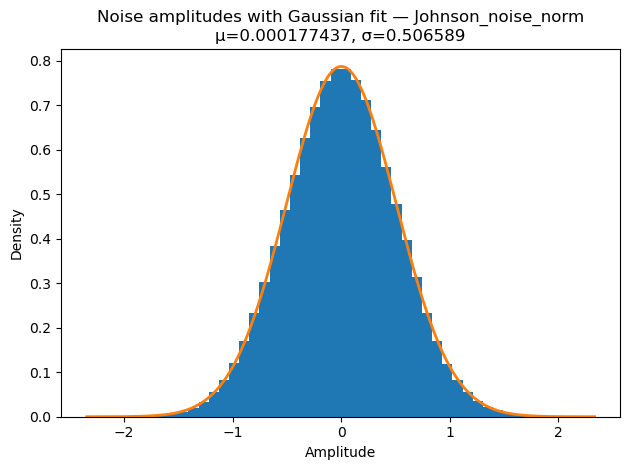

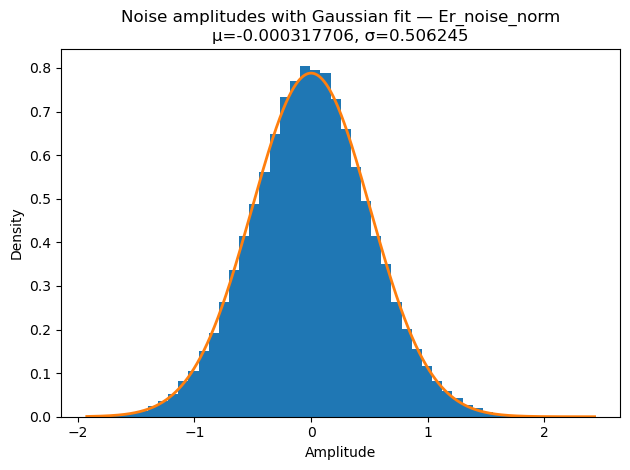

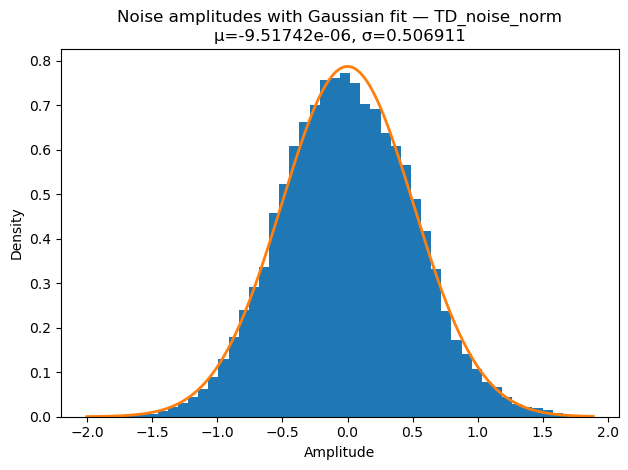

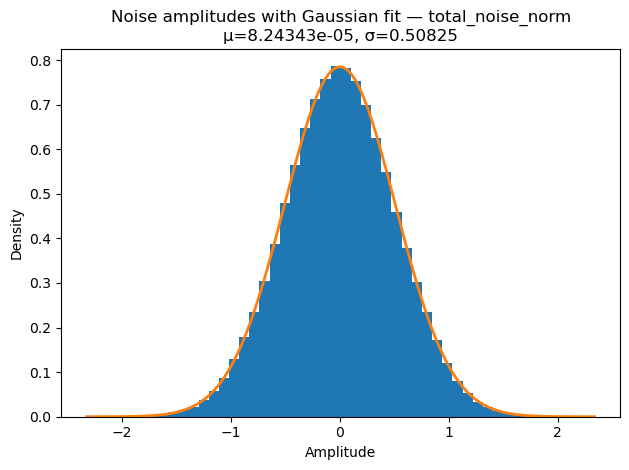

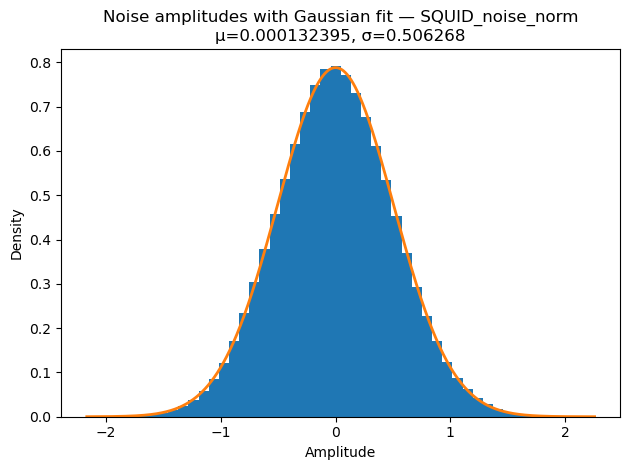


=== Summary (per noise PSD) ===
PSD                           mu         sigma  n_amps  (key)
noise_psd_xray       0.000202968      0.505738  4967233  (noise_type)
Johnson_noise_norm   0.000177437      0.506589  4967233  (noise_type)
Er_noise_norm       -0.000317706      0.506245  4967233  (noise_type)
TD_noise_norm       -9.51742e-06      0.506911  4967233  (noise_type)
total_noise_norm     8.24343e-05       0.50825  4967233  (noise_type)
SQUID_noise_norm     0.000132395      0.506268  4967233  (noise_type)


In [1]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from TraceSimulator import LongTraceSimulator
from TraceSimulator import NoiseGenerator
from OptimumFilter import OptimumFilter

# ---------- config helpers ----------
def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as f:
        return yaml.safe_load(f)

def set_noise_psd_path(config: dict, psd_path: str):
    """
    Update the config to point to the given PSD path.
    Tries a few common keys; creates 'noise_type' if nothing matches.
    """
    # Try nested structure first
    if isinstance(config.get("noise"), dict) and "psd_path" in config["noise"]:
        config["noise"]["psd_path"] = psd_path
        return config, "noise.psd_path"
    # Try flat keys
    if "noise_psd_path" in config:
        config["noise_psd_path"] = psd_path
        return config, "noise_psd_path"
    if "noise_type" in config:
        config["noise_type"] = psd_path
        return config, "noise_type"
    # Fallback: create a simple key
    config["noise_type"] = psd_path
    return config, "noise_type"

# ---------- user inputs ----------
yaml_path = "/home/dwong/DELight_mtr/trigger_study/wk22/standardized_flow_center/calibration_config.yaml"
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
OF_psd = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"
fs = 3_906_250  # Hz
trace_len = 5_000_000  # samples for noise generation

psd_paths = [
    "/ceph/dwong/delight_conf/new/noise_psd_xray.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/Johnson_noise_norm.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/Er_noise_norm.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/TD_noise_norm.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/total_noise_norm.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/SQUID_noise_norm.npy",
]

# ---------- load base config ----------
base_config = read_yaml_to_dict(yaml_path)

# ---------- run loop ----------
summary = []  # list of dicts with name, mu, sigma, key_used
for psd_path in psd_paths:
    # 1) update config in-memory
    config = yaml.safe_load(yaml.dump(base_config))  # deep copy via yaml round-trip
    config, key_used = set_noise_psd_path(config, psd_path)

    # 2) regenerate noise with this PSD
    lts = LongTraceSimulator(config)
    ng = NoiseGenerator(config)
    noise_trace = ng.generate_noise(trace_len).astype(np.float32)

    # 3) build OptimumFilter with the same PSD
    noise_psd = np.load(OF_psd)
    worker = OptimumFilter(sub_template, noise_psd, fs)

    # 4) slide to get amplitudes
    amps, _ = worker.sliding_fit(noise_trace, hop=1, reanchor_every=None, chisq_mode="none")

    # 5) fit Gaussian to amplitudes
    mu, sigma = norm.fit(amps)

    # 6) histogram + Gaussian curve (one chart per config, no explicit colors/styles)
    counts, bins, patches = plt.hist(amps, bins=50, density=True)
    x = np.linspace(float(np.min(amps)), float(np.max(amps)), 1000)
    pdf = norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, linewidth=2)
    fname = os.path.splitext(os.path.basename(psd_path))[0]
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title(f"Noise amplitudes with Gaussian fit — {fname}\nμ={mu:.6g}, σ={sigma:.6g}")
    plt.tight_layout()
    plt.show()

    # 7) collect summary
    summary.append({
        "psd_name": fname,
        "psd_path": psd_path,
        "config_key": key_used,
        "mu": float(mu),
        "sigma": float(sigma),
        "n_amps": int(len(amps)),
    })

# ---------- print summary ----------
print("\n=== Summary (per noise PSD) ===")
w_name = max(len(s["psd_name"]) for s in summary)
w_sigma = 12
w_mu = 12
print(f"{'PSD':{w_name}}  {'mu':>{w_mu}}  {'sigma':>{w_sigma}}  n_amps  (key)")
for s in summary:
    print(f"{s['psd_name']:{w_name}}  {s['mu']:>{w_mu}.6g}  {s['sigma']:>{w_sigma}.6g}  {s['n_amps']:>6d}  ({s['config_key']})")
